<a href="https://colab.research.google.com/github/anish00ti/EDA-on-sales/blob/main/notebook/bivarient_and_multivarient_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/anish00ti/EDA-on-sales.git

Cloning into 'EDA-on-sales'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 101 (delta 37), reused 41 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 5.01 MiB | 13.10 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv("EDA-on-sales/data/cleaned/cleaned_sales.csv")

In [29]:
df.dtypes

,0
order_date,datetime64[ns]
ship_date,datetime64[ns]
ship_mode,category
segment,category
country,category
city,object
state,object
region,category
category,category
sub_category,object


In [25]:
df['order_month']=df['order_month'].astype("category")

In [7]:
df["order_date"] = pd.to_datetime(df["order_date"],format='mixed', errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"],format='mixed', errors="coerce")

In [23]:
# identify categorical columns and convert into category datatype
for col in df.columns:
    if df[col].nunique() < 10:   # we maka a assumption that if a column has less than 10 unique values, it is a categorical column
        print(col)
        df[col] = df[col].astype("category")

ship_mode
segment
country
region
category
payment_mode
order_year
order_weekday
shipping_days


In [ ]:
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

# Integer columns
integer_cols = df.select_dtypes(include=['int64',"float64" ,'int32']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Integer Columns:", integer_cols)

In [11]:
df.columns

Index(['Row ID+O6G3A1:R6', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'profit', 'payment_mode'],
      dtype='object')

In [28]:
df=df.drop(columns=["customer_name"])

### Interpretation for Dropping Columns (Concise)

The columns 'Row ID+O6G3A1:R6', 'order_id', 'customer_id', and 'product_id' were dropped because they are unique identifiers. For Exploratory Data Analysis (EDA) focused on general sales trends and patterns, these unique IDs typically do not provide direct analytical value compared to their descriptive counterparts (e.g., product name, customer segment), which were retained.

In [14]:
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_weekday'] = df['order_date'].dt.day_name()

df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

<Axes: >

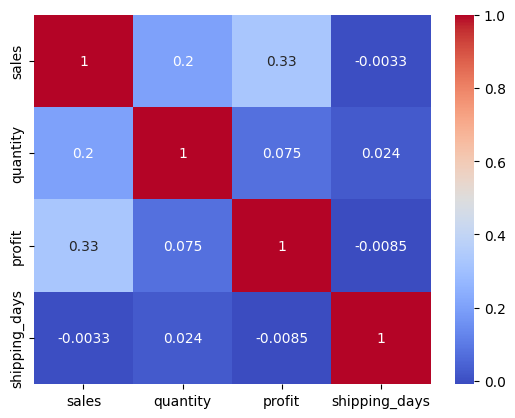

In [18]:
num_cols = ['sales','quantity','profit','shipping_days']

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

<Axes: xlabel='sales', ylabel='profit'>

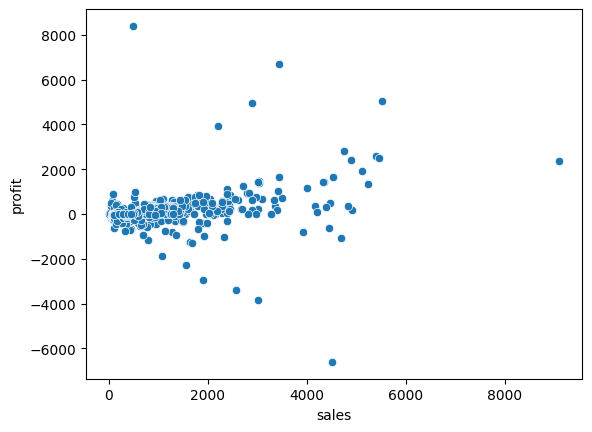

In [17]:
sns.scatterplot(
    data=df,
    x='sales',
    y='profit'
)

 Sales vs. Profit

This plot shows a general positive trend: higher sales typically lead to higher profits. However, it also highlights significant profit variability at all sales levels, including notable losses even for high-volume sales. This suggests that while sales are important, other factors like product costs, discounts, or operational efficiency are heavily impacting the final profitability of transactions.

<Axes: xlabel='sales', ylabel='quantity'>

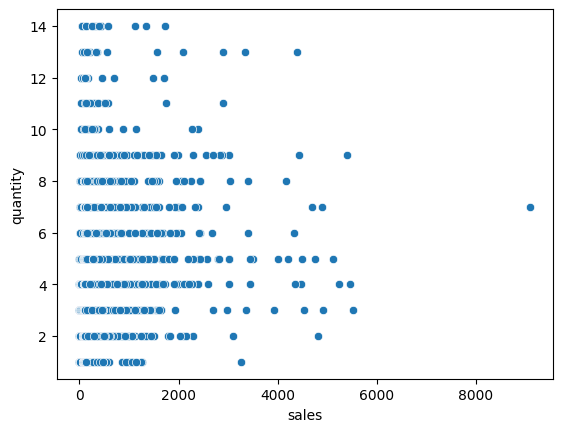

In [19]:
sns.scatterplot(data=df, x='sales', y='quantity')

region              Central        East       South        West
category                                                       
Furniture        -1534.7880   3621.5039   2562.0203   5357.8750
Office Supplies   6477.6297  23248.6104  11104.9759  33966.0301
Technology       22507.1654  26530.3100  12884.7201  28536.0531


/tmp/ipykernel_3513/2607190192.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(index='category', columns='region', values='profit', aggfunc='sum')


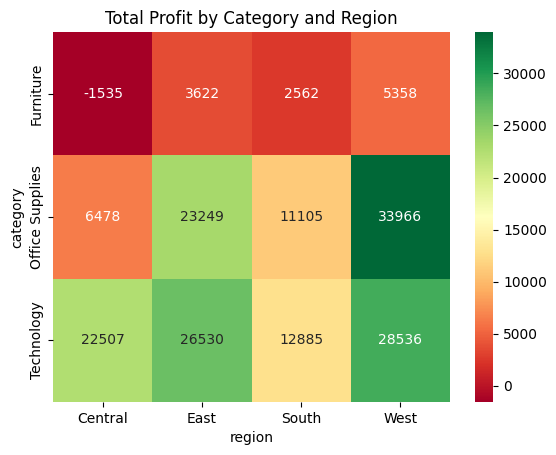

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Multivariate: Profit by Category and Region
pivot_data = df.pivot_table(index='category', columns='region', values='profit', aggfunc='sum')
print(pivot_data)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', fmt='.0f')
plt.title('Total Profit by Category and Region')
plt.show()

<Axes: xlabel='region', ylabel='sales'>

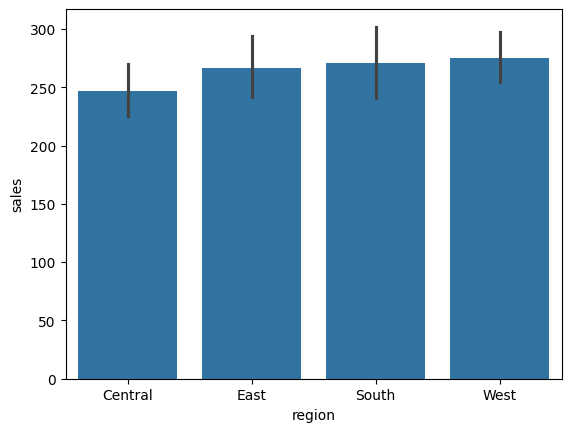

In [30]:
sns.barplot(x="region" , y="sales", data=df)

In [38]:
monthly_sales=df.groupby(['order_month'])['sales'].agg(sum="sum").reset_index()
print(monthly_sales)

   order_month          sum
0            1   73379.8050
1            2   72046.9484
2            3  115945.2278
3            4   89557.5751
4            5  117737.8382
5            6  109587.2597
6            7   99339.3790
7            8  108454.2623
8            9  193213.6769
9           10  131584.6682
10          11  210372.7908
11          12  244584.8918


/tmp/ipykernel_3513/2131631296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales=df.groupby(['order_month'])['sales'].agg(sum="sum").reset_index()


<Axes: xlabel='order_month', ylabel='sum'>

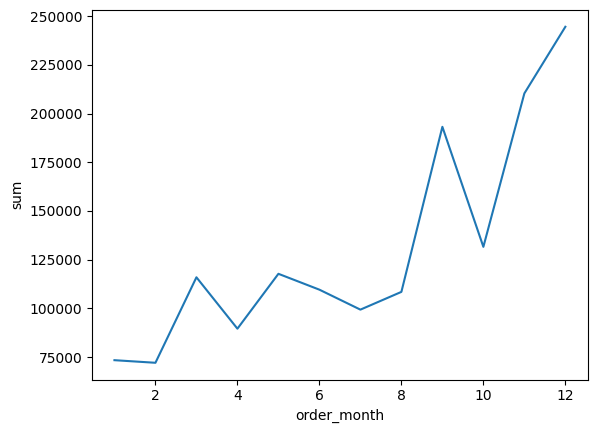

In [41]:
sns.lineplot(data=monthly_sales , x='order_month' , y='sum')

### Interpretation of Monthly Sales Trend

The line plot illustrates the sum of sales for each month across the entire dataset. From this visualization, we can observe the following trends:

1.  **Seasonal Pattern**: There appears to be a clear seasonal pattern in sales. Sales generally start lower at the beginning of the year, pick up gradually, and then see a significant surge towards the end of the year.

2.  **Peak Sales Months**: The months of September, November, and December consistently show the highest sales figures. This often indicates strong holiday season shopping or end-of-year purchasing trends.

3.  **Lower Sales Months**: Conversely, months like January and February tend to have the lowest sales volumes, which is typical after the holiday season.

4.  **Growth Throughout the Year**: Beyond the peaks and troughs, there's a general upward trend in sales as the year progresses from early months to later months, suggesting a build-up of purchasing activity.

In summary, the plot highlights strong seasonality in sales, with a clear upward trajectory towards the year-end, peaking in the last few months.

<Axes: xlabel='category', ylabel='sales'>

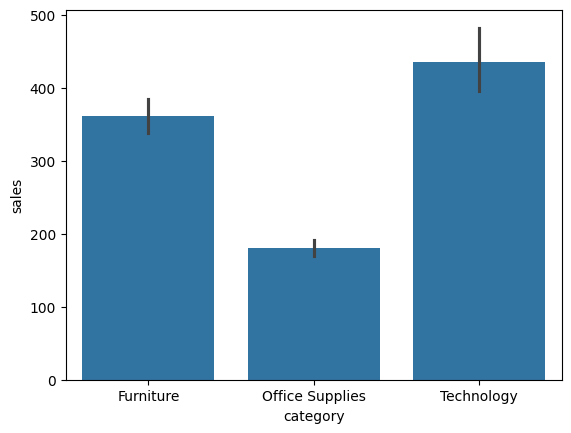

In [45]:
sns.barplot(data=df , x="category", y="sales",estimator=np.mean)

### Interpretation of Average Sales by Category Bar Plot

This bar plot visualizes the *mean* sales across different product categories. Here are the key observations:

1.  **Technology Leads in Average Sales**: The 'Technology' category clearly has the highest average sales per transaction. This suggests that individual technology products, when sold, tend to generate significantly more revenue than products from other categories.

2.  **Furniture is Second**: 'Furniture' comes in second, with a moderate average sales value, but noticeably lower than Technology. This indicates that while furniture items contribute substantially to sales, they don't reach the same average revenue per sale as technology products.

3.  **Office Supplies are Lowest**: 'Office Supplies' have the lowest average sales. This is expected, as many office supply items are typically lower-priced commodities. While they might be sold in higher quantities or more frequently, individual transactions contribute less on average to total sales revenue.

In summary, the plot highlights the varying revenue contributions of each product category per sale, with Technology leading, followed by Furniture, and Office Supplies having the lowest average sales.

<Axes: xlabel='category', ylabel='profit'>

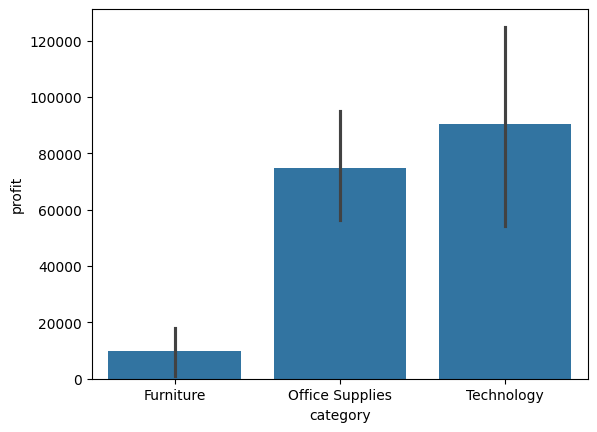

In [48]:
sns.barplot(data=df , x='category', y='profit',estimator=np.sum)

In [16]:
df.sample(5)

,order_date,ship_date,ship_mode,customer_name,segment,country,city,state,region,category,...,product_name,sales,quantity,profit,payment_mode,order_year,order_month,order_day,order_weekday,shipping_days
1727,2019-10-13,2019-10-19,Standard Class,Lena Creighton,Consumer,United States,Roseville,California,West,Office Supplies,...,Xerox 195,20.040,3,9.6192,COD,2019,10,13,Sunday,6
5282,2020-11-19,2020-11-22,First Class,Adrian Shami,Home Office,United States,New York City,New York,East,Office Supplies,...,Xerox 1898,103.360,2,6.4128,Cards,2020,11,19,Thursday,3
5090,2020-11-06,2020-11-13,Standard Class,Valerie Mitchum,Home Office,United States,Westfield,New Jersey,East,Office Supplies,...,Decoflex Hanging Personal Folder File,133.260,3,12.0276,COD,2020,11,6,Friday,7
179,2019-03-03,2019-03-08,Standard Class,Brosina Hoffman,Consumer,United States,Newark,Delaware,East,Technology,...,Pyle PMP37LED,479.950,5,129.5865,COD,2019,3,3,Sunday,5
1964,2019-11-10,2019-11-12,First Class,Chuck Clark,Home Office,United States,San Francisco,California,West,Office Supplies,...,"ACCOHIDE 3-Ring Binder, Blue, 1""",13.216,4,4.4604,COD,2019,11,10,Sunday,2
